---
title: "Aggregate Statistics Comparisons"
authors:
  - name: James Butler
    affiliations: ucb
  - name: Michelle Maclennan
    affiliation: bas
  - name: Fernando Pérez
    affiliation: ucb
  - name: Jon McAuliffe
    affiliation: ucb
affiliations:
  - id: ucb
    institution: University of California Berkeley
    ror: https://ror.org/01an7q238
    department: Statistics
  - id: bas
    institution: British Antarctic Survey
    ror: https://ror.org/01rhff309
---

To further validate our catalog, in addition to ensuring we properly identified known storms presented in case studies, we also check that we are able to reproduce AR count statistics, by year and by geographic location, reported in the literature.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
import pandas as pd
import xarray as xr
import seaborn as sns
import os
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.path as mpath
from scipy.stats import linregress
from huggingface_hub import login, hf_hub_download

from artools.attribute_utils import *
from artools.loading_utils import *

/home/jovyan/antarctic_AR_dataset/notebooks/quality_assurance


In [2]:
# loading up the ais and catalogs
ais_mask = load_ais()
df = load_catalog('epsspace0.5_epstime12_minpts5_nreppts10_seed12345.h5')
landfalling_df = df[df.is_landfalling]

In [3]:
# add in landfalling times and durations
landfalling_df['landfalling_duration'] = landfalling_df['data_array'].apply(compute_duration, ais_da=ais_mask)
landfalling_df['landfalling_start_date'] = landfalling_df['data_array'].apply(add_start_date, ais_da=ais_mask)
landfalling_df['landfalling_end_date'] = landfalling_df['data_array'].apply(add_end_date, ais_da=ais_mask)

## Histograms of Landfalling Locations

We first reproduce Figure 1b of [Synoptic and planetary-scale dynamics modulate Antarctic atmospheric river precipitation intensity](https://doi.org/10.1038/s43247-024-01307-9) using data from our catalog. For ease of comparison, we replot their figure with our own plotting code, with the same underlying data as in the original figure (provided by the authors).

To make this plot, we first write a function that, given an AR's data array, finds all of the average longitudes across the $55^{\circ}$ S latitude for each time step the AR passes through.

In [5]:
def get_avg_landfall_lons(da, target_lat=-55):

    # force coordinates to be the same (avoid floating point errors)
    clean_lat = ais_mask.sel(lat=da.lat, method="nearest").lat
    clean_lon = ais_mask.sel(lon=da.lon, method="nearest").lon
    da = da.assign_coords(lat=clean_lat, lon=clean_lon)
    
    # subset time steps where AR is actively making landfall
    ais_mask_subset = ais_mask.sel(lat=da.lat, lon=da.lon)
    ais_storm_mask = da*ais_mask_subset
    landfall_times = da.time[ais_storm_mask.any(dim=['lat', 'lon'])]
    landfall_da = da.sel(time=landfall_times)

    da_lat = landfall_da.sel(lat=target_lat, method='nearest')
    mask = da_lat.astype(float)
    counts = mask.sum(dim='lon')
    
    # convert coordinates to radians and calculate Cartesian
    lat_rad = np.radians(da_lat.lat)
    lon_rad = np.radians(da_lat.lon)
    x = np.cos(lat_rad)*np.cos(lon_rad)
    y = np.cos(lat_rad)*np.sin(lon_rad)
    
    # calculate the average x and y only where the mask == 1
    avg_x = (x*mask).sum(dim='lon')/counts
    avg_y = (y*mask).sum(dim='lon')/counts
    
    avg_lon_rad = np.arctan2(avg_y, avg_x)
    avg_lon_deg = np.degrees(avg_lon_rad)
    
    avg_lon_deg = avg_lon_deg.where(counts > 0, np.nan)
    
    return avg_lon_deg

Then, we apply this function to all of the ARs and organize the average longitudes into a list, such that we have a list of average longitudes at each AR timestep.

In [6]:
mean_lons_list = [get_avg_landfall_lons(ar.data_array, target_lat=-55) for index, ar in landfalling_df.iterrows()]
all_mean_lons = np.concatenate([m.values for m in mean_lons_list])
# filter out NaNs (storms that never crossed 55 S)
clean_mean_lons = all_mean_lons[~np.isnan(all_mean_lons)]

We also load up the original longitude data used in the figure we are reproducing.

In [9]:
original_lons = pd.read_csv('../../input_data/reproducing_plots_data/baiman2024_1b_original.csv')
original_lons = np.array(original_lons.center_55)

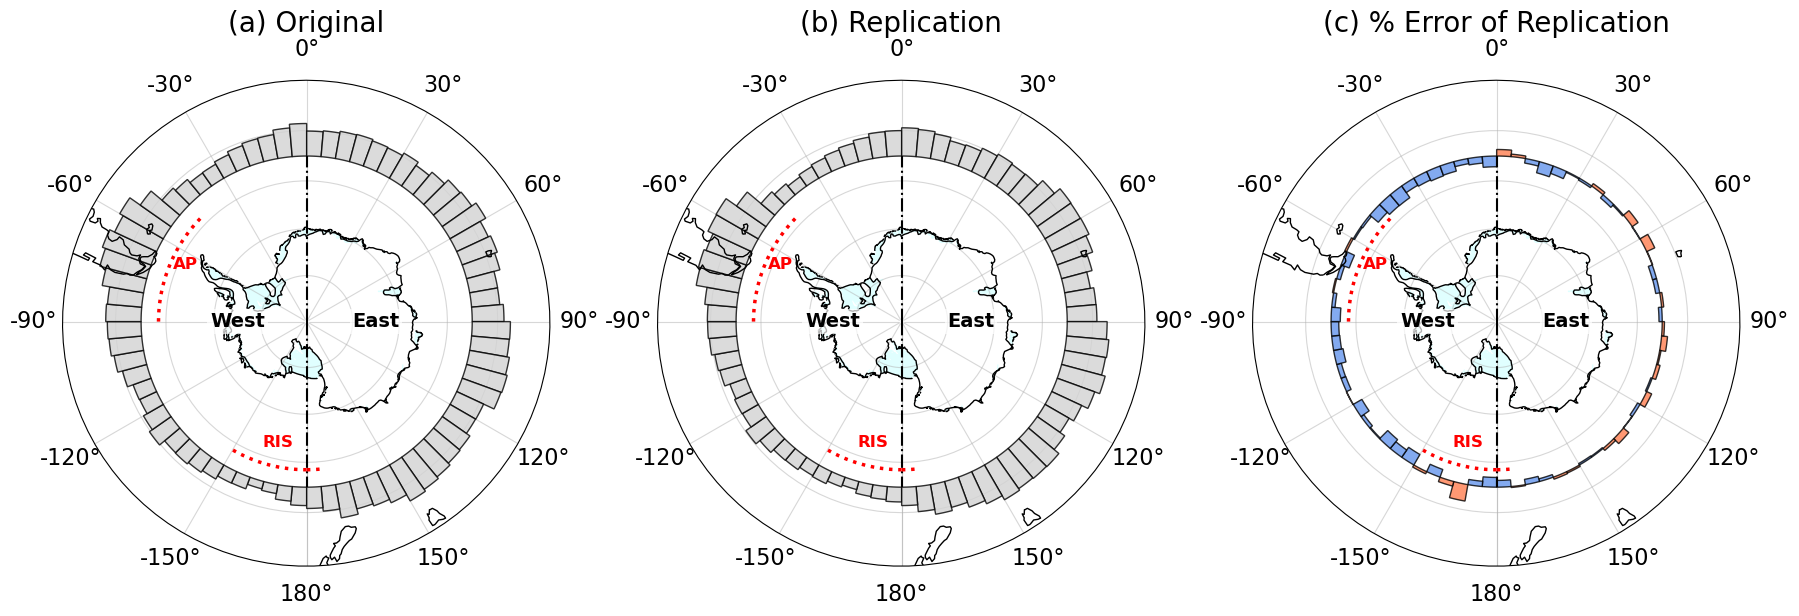

In [15]:
fig, axs = plt.subplots(1, 3, figsize=(18, 6), subplot_kw={'projection': ccrs.Stereographic(central_longitude=0., central_latitude=-90.)})

ice_shelf_poly = cfeature.NaturalEarthFeature('physical', 'antarctic_ice_shelves_polys', '50m', edgecolor='none', facecolor='lightcyan')
ice_shelf_line = cfeature.NaturalEarthFeature('physical', 'antarctic_ice_shelves_lines', '50m', edgecolor='black', facecolor='none')

# longitudes to plot in grid
longitudes = np.arange(-6,7)*30
# latitude for degree labels
label_lat = -35
# latitude at which to indicate regions of interest via arcs
roi_lat = -58.5
roi_dict = {'AP': [-90, -45],
            'RIS': [175, -150]}

# adding plot decorations (everything except for the histograms)
for ax in axs:
    ax.add_feature(ice_shelf_poly, linewidth=3)
    ax.add_feature(ice_shelf_line, linewidth=1, zorder=13)
    ax.coastlines(resolution='110m', linewidth=1, zorder=32)
    ax.set_extent([-180, 180, -90, -40], ccrs.PlateCarree())
    ax.grid(True, linestyle='--', color='gray', alpha=0.5)
    
    # circular boundary
    theta = np.linspace(0, 2*np.pi, 100)
    center, radius = [0.5, 0.5], 0.5
    verts = np.vstack([np.sin(theta), np.cos(theta)]).T
    circle = mpath.Path(verts * radius + center)
    ax.set_boundary(circle, transform=ax.transAxes)
    ax.gridlines(alpha=0.5, zorder=33, xlocs=longitudes)

    # vertical line down middle to distinguish East v. West Antarctica
    ax.plot([0, 0], [-90, -55], transform=ccrs.PlateCarree(),
        color='black', linewidth=1.5, linestyle='-.', zorder=34)
    ax.plot([180, 180], [-90, -55], transform=ccrs.PlateCarree(),
        color='black', linewidth=1.5, linestyle='-.', zorder=34)

    # hemisphere labels
    ax.text(-90, -75, 'West', transform=ccrs.PlateCarree(),
        ha='center', va='center', fontsize=14, fontweight='bold',
        zorder=37,
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.7, pad=2))
    ax.text(90, -75, 'East', transform=ccrs.PlateCarree(),
        ha='center', va='center', fontsize=14, fontweight='bold',
        zorder=37,
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.7, pad=2))

    # add labels for all longitudes except -180, which is just 180
    for lon in longitudes[1:]:
        label = f'{lon}°'

        ax.text(lon, label_lat, label,
                transform=ccrs.PlateCarree(),
                ha='center', va='center',
                fontsize=16, zorder=40)

    for roi_name, (lon_start, lon_end) in roi_dict.items():
        # convention: if provided starting lon is smaller than end, arc drawn as normal
        # if the starting lon is higher, than we will wrap around 180
        if lon_start <= lon_end:
            arc_lons = np.linspace(lon_start, lon_end, 100)
            arc_lats = np.full_like(arc_lons, roi_lat)
            ax.plot(arc_lons, arc_lats,
                transform=ccrs.PlateCarree(),
                color='red', linewidth=2.5, zorder=35, linestyle='dotted')
            # for plotting the labels
            mid_lon = (lon_start + lon_end) / 2
        else:
            # lon_start > lon_end: assume the region wraps through 180
            seg1_lons = np.linspace(lon_start, 180, 50)
            seg2_lons = np.linspace(-180, lon_end, 50)
            ax.plot(seg1_lons, np.full_like(seg1_lons, roi_lat),
                transform=ccrs.PlateCarree(),
                color='red', linewidth=2.5, zorder=35, linestyle='dotted')
            ax.plot(seg2_lons, np.full_like(seg2_lons, roi_lat),
                transform=ccrs.PlateCarree(),
                color='red', linewidth=2.5, zorder=35, linestyle='dotted')

            # for plotting the labels
            total_span = (180 - lon_start) + (lon_end - (-180))
            mid_offset = total_span / 2
            mid_lon = lon_start + mid_offset
            if mid_lon > 180:
                mid_lon -= 360

        ax.text(mid_lon, roi_lat - 3.5, roi_name,
            transform=ccrs.PlateCarree(),
            ha='center', va='bottom',
            fontsize=12, color='red', fontweight='bold',
            zorder=36)

axs[0].set_title('(a) Original', pad=35, fontsize=20)
axs[1].set_title('(b) Replication', pad=35, fontsize=20)
axs[2].set_title('(c) % Error of Replication', pad=35, fontsize=20)

num_bins = 72
counts, bin_edges = np.histogram(clean_mean_lons, bins=num_bins, range=(-180, 180), density=False)
counts_orig, bin_edges_orig = np.histogram(original_lons, bins=num_bins, range=(-180, 180), density=False)

# calculate percent error of our bin counts relative to the original
percent_error = (counts - counts_orig) / counts_orig * 100

baseline_lat = -55
max_lat_stretch = 10 

global_max = max(counts.max(), counts_orig.max())

# scale raw counts and original counts
scaled_heights = (counts / global_max) * max_lat_stretch
scaled_heights_orig = (counts_orig / global_max) * max_lat_stretch

# compute scaled percent errors
pe_cap = 100.0
scaled_pe = np.clip(percent_error, -pe_cap, pe_cap) / pe_cap * max_lat_stretch

# drawing the polygons
for i in range(len(counts)):
    lon1, lon2 = bin_edges[i], bin_edges[i+1]
    lons = np.linspace(lon1, lon2, 10)
    
    # common elements
    baseline_lat_vec = np.full_like(lons, baseline_lat)
    
    # plot original (axs[0])
    if counts_orig[i] > 0:
        lat_top_orig = baseline_lat + scaled_heights_orig[i]
        top_edge_orig = np.column_stack((lons, np.full_like(lons, lat_top_orig)))
        bottom_edge_orig = np.column_stack((lons[::-1], baseline_lat_vec))
        verts_orig = np.vstack((top_edge_orig, bottom_edge_orig))
        
        poly_orig = Polygon(verts_orig, facecolor='lightgray', edgecolor='black', 
                            transform=ccrs.PlateCarree(), alpha=0.8, zorder=10)
        axs[0].add_patch(poly_orig)

    # plot replication (axs[1])
    if counts[i] > 0:
        lat_top = baseline_lat + scaled_heights[i]
        top_edge = np.column_stack((lons, np.full_like(lons, lat_top)))
        bottom_edge = np.column_stack((lons[::-1], baseline_lat_vec))
        verts = np.vstack((top_edge, bottom_edge))
        
        poly = Polygon(verts, facecolor='lightgray', edgecolor='black', 
                       transform=ccrs.PlateCarree(), alpha=0.8, zorder=10)
        axs[1].add_patch(poly)
        
    # plot percent error (axs[2])
    if percent_error[i] != 0:
        lat_2 = baseline_lat + scaled_pe[i]
        top_edge_diff = np.column_stack((lons, np.full_like(lons, lat_2)))
        bottom_edge_diff = np.column_stack((lons[::-1], baseline_lat_vec))
        verts_diff = np.vstack((top_edge_diff, bottom_edge_diff))
    
        # coral = replication overcounts, cornflowerblue = replication undercounts
        diff_color = 'coral' if percent_error[i] > 0 else 'cornflowerblue'
    
        poly_diff = Polygon(verts_diff, facecolor=diff_color, edgecolor='black',
                            transform=ccrs.PlateCarree(), alpha=0.8, zorder=10)
        axs[2].add_patch(poly_diff)

plt.tight_layout()
fig.savefig('../../output/plots/reproduce_longitudinal_hist_directional.png', dpi=300, bbox_inches='tight')
plt.show()

We see similarities in the distribution of average longitudes between our plot and the original. For instance, we see higher counts around longitudes near the Antarctic Peninsula, steady amounts across East Antarctic longitudes, and the lowest counts near the Ross Ice Shelf. Let's look at the maximum positive percent error (indicating overestimations relative to the original study) and the maximum negative percent error (indicating underestimatoins relative to the original study).

In [36]:
max(percent_error)

np.float64(32.89473684210527)

In [35]:
min(percent_error)

np.float64(-28.57142857142857)

### Durations and Counts in West Antarctica

Next, we seek to reproduce various statistics and figures from [Climatology and surface impacts of atmospheric rivers on West Antarctica](https://doi.org/10.5194/tc-17-865-2023) by Maclennan et al., which conducts an extensive analysis of AR landfall counts and durations in Marie Byrd Land and the Amnudsen Sea Embayment.

We first define two functions, one which determines if an AR falls at all within a spatial bounding box, and also for how many hours the storm spends in the the bounding box.

In [94]:
def is_in_region(da, lat_low, lat_high, lon_low, lon_high):
    in_region = da.where((da.lat <= lat_high) & 
                         (da.lat >= lat_low) & 
                         (da.lon <= lon_high) & 
                         (da.lon >= lon_low), drop=True).any().values
    return in_region

def duration_in_region(da, lat_low, lat_high, lon_low, lon_high):
    region_mask = da.where((da.lat <= lat_high) & 
                           (da.lat >= lat_low) & 
                           (da.lon <= lon_high) & 
                           (da.lon >= lon_low), drop=True)
    times = region_mask.time[region_mask.any(dim=['lat', 'lon'])]
    duration = (times.values[-1] - times.values[0]).astype('timedelta64[h]') + np.timedelta64(3, 'h')

    return duration

We count a storm as making landfall in Marie Byrd Land/Amundsen Sea Embayment if it intsersects $72.5^{\circ}$ S, between $150^{\circ}$ W and $80^{\circ}$ W. The duration of landfall is counted as the elapsed time between the first time it passes through the region defined by these longitudes and between $80^{\circ}$ S and $72.5^{\circ}$ S, and the last. We choose the coordinate $72.5^{\circ}$ S beceause this arc roughly corresponds to the coastline, and $150^{\circ}$ W and $80^{\circ}$ W as this range roughly covers the geographic region of interest. The original paper uses ARs defined up to $80^{\circ}$ S. The figure below plots the regions of interest, shading our defined region in orange.

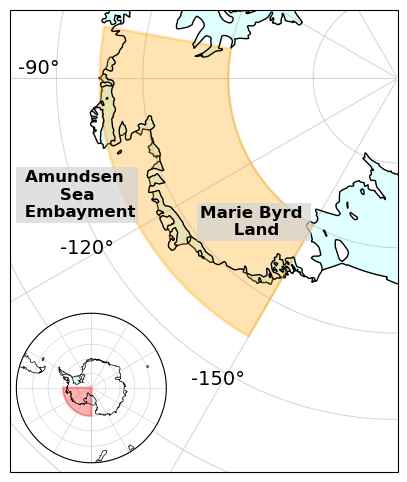

In [91]:
fig = plt.figure(figsize=(6, 6))

main_proj = ccrs.Stereographic(central_longitude=0, central_latitude=-90)
ax_main = fig.add_subplot(1, 1, 1, projection=main_proj)

# inset axis for the full circumpolar view
inset_proj = ccrs.Stereographic(central_longitude=0, central_latitude=-90)
ax_inset = fig.add_axes([0.2, 0.125, 0.25, 0.25], projection=inset_proj)

# longitudes for gridlines
longitudes = np.arange(-6, 7) * 30

# features for both axes
ice_shelf_poly = cfeature.NaturalEarthFeature('physical', 'antarctic_ice_shelves_polys',
                                              '50m', edgecolor='none', facecolor='lightcyan')
ice_shelf_line = cfeature.NaturalEarthFeature('physical', 'antarctic_ice_shelves_lines',
                                              '50m', edgecolor='black', facecolor='none')

# main axis showcasing MBL and ASE
ax_main.add_feature(ice_shelf_poly, linewidth=3)
ax_main.add_feature(ice_shelf_line, linewidth=1, zorder=13)
ax_main.coastlines(resolution='50m', linewidth=1, zorder=32)
ax_main.set_extent([-180, -80, -90, -67], ccrs.PlateCarree())
ax_main.gridlines(alpha=0.5, zorder=33, xlocs=longitudes, draw_labels=False)

ax_main.text(-110, -70, 'Amundsen \n Sea \n Embayment',
             transform=ccrs.PlateCarree(),
             ha='center', va='center',
             fontsize=12, fontweight='bold',
             zorder=40,
             bbox=dict(facecolor='lightgray', edgecolor='none', alpha=0.7, pad=2))

ax_main.text(-135, -78, 'Marie Byrd \n Land',
             transform=ccrs.PlateCarree(),
             ha='center', va='center',
             fontsize=12, fontweight='bold',
             zorder=40,
             bbox=dict(facecolor='lightgray', edgecolor='none', alpha=0.7, pad=2))

# shade ASE/MBL region on main map
ase_lon_start, ase_lon_end = -150, -80
ase_lat_min, ase_lat_max = -80, -72.5

ase_lons = np.concatenate([
    np.linspace(ase_lon_start, ase_lon_end, 50),    # top edge (along -72.5)
    np.full(50, ase_lon_end),                       # east edge (down -80 lon)
    np.linspace(ase_lon_end, ase_lon_start, 50),    # bottom edge (along -80 lat)
    np.full(50, ase_lon_start),                     # west edge (up -150)
])
ase_lats = np.concatenate([
    np.full(50, ase_lat_max),
    np.linspace(ase_lat_max, ase_lat_min, 50),
    np.full(50, ase_lat_min),
    np.linspace(ase_lat_min, ase_lat_max, 50),
])

ax_main.fill(ase_lons, ase_lats,
             transform=ccrs.PlateCarree(),
             facecolor='orange', alpha=0.3, edgecolor='orange',
             linewidth=2, zorder=15)


# longitude labels along the edge of the main map
# place them just outside the -70 latitude extent
label_lat_main = -69
main_label_lons = [-90, -150, -120]
for lon in main_label_lons:
    label = f'{lon}°'
    ax_main.text(lon, label_lat_main, label,
                 transform=ccrs.PlateCarree(),
                 ha='center', va='bottom',
                 fontsize=14, zorder=40)

ax_main.set_title('', pad=15, fontsize=18)

# add inset figure with circumpolar view of Antarctica + shaded region
ax_inset.add_feature(ice_shelf_poly, linewidth=1)
ax_inset.add_feature(ice_shelf_line, linewidth=0.5, zorder=13)
ax_inset.coastlines(resolution='110m', linewidth=0.5, zorder=32)
ax_inset.set_extent([-180, 180, -90, -40], ccrs.PlateCarree())

# circular boundary for the inset
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)
ax_inset.set_boundary(circle, transform=ax_inset.transAxes)
ax_inset.gridlines(alpha=0.5, zorder=33, xlocs=longitudes, linewidth=0.5)

# shade the region of interest on the inset figure
roi_lon_start, roi_lon_end = -180, -90
roi_lat_min, roi_lat_max = -90, -70

box_lons = np.concatenate([
    np.linspace(roi_lon_start, roi_lon_end, 50),    # top edge (along -70)
    np.full(50, roi_lon_end),                       # east edge (down -80)
    np.linspace(roi_lon_end, roi_lon_start, 50),    # bottom edge (along -90)
    np.full(50, roi_lon_start),                     # west edge (up -180)
])
box_lats = np.concatenate([
    np.full(50, roi_lat_max),
    np.linspace(roi_lat_max, roi_lat_min, 50),
    np.full(50, roi_lat_min),
    np.linspace(roi_lat_min, roi_lat_max, 50),
])

ax_inset.fill(box_lons, box_lats,
              transform=ccrs.PlateCarree(),
              facecolor='red', alpha=0.3, edgecolor='red',
              linewidth=1.5, zorder=20);

plt.savefig('../../output/plots/mbl_ase_focus.png', dpi=300, bbox_inches='tight')
plt.show()

In [95]:
landfalling_df['in_MBL_ASE'] = landfalling_df['data_array'].apply(lambda x: is_in_region(x, -72.5, -72.5, -150, -80))
mbl_ase_storms = landfalling_df[landfalling_df.in_MBL_ASE]
mbl_ase_storms['duration_MBL_ASE'] = mbl_ase_storms['data_array'].apply(lambda x: duration_in_region(x, -80, -72.5, -150, -80))

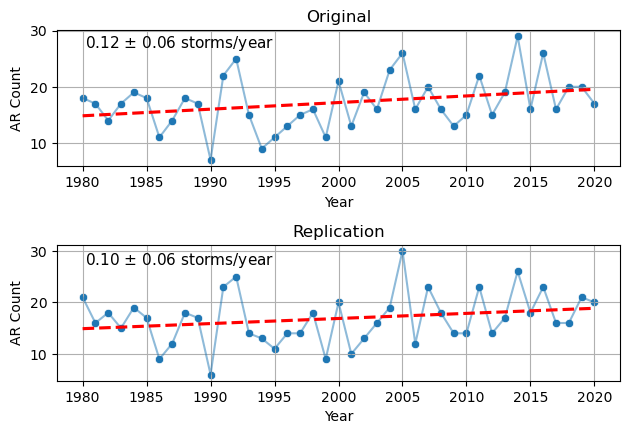

In [96]:
fig, axs = plt.subplots(2, 1)

# get plotting dataframe for replication
num_storms = mbl_ase_storms.groupby(mbl_ase_storms.landfalling_start_date.dt.year, as_index=False).size()
num_storms = num_storms[num_storms.landfalling_start_date <= 2020]

# get original counts dataframe
original_counts = pd.read_csv('../../input_data/reproducing_plots_data/maclennan2023_3a_original.csv')

# create original plot
x = original_counts['Year']
y = original_counts['Landfall_Events']
slope, intercept, r_value, p_value, std_err = linregress(x, y)
sns.lineplot(data=original_counts, x='Year', y='Landfall_Events', alpha=0.5, ax=axs[0])
sns.scatterplot(data=original_counts, x='Year', y='Landfall_Events', ax=axs[0])
sns.regplot(data=original_counts, x='Year', y='Landfall_Events', 
            scatter=False, color='red', line_kws={'linestyle': '--'}, ci=None, ax=axs[0])

axs[0].set_title('Original')
axs[0].set_xlabel('Year')
axs[0].set_ylabel('AR Count')
text_box = f"{slope:.2f} $\\pm$ {std_err:.2f} storms/year"
axs[0].text(0.05, 2.45, text_box, 
         transform=plt.gca().transAxes, 
         fontsize=11, color='black')
axs[0].grid()

# create replication plot
x = num_storms['landfalling_start_date']
y = num_storms['size']
slope, intercept, r_value, p_value, std_err = linregress(x, y)
sns.lineplot(data=num_storms, x='landfalling_start_date', y='size', alpha=0.5, ax=axs[1])
sns.scatterplot(data=num_storms, x='landfalling_start_date', y='size', ax=axs[1])
sns.regplot(data=num_storms, x='landfalling_start_date', y='size', 
            scatter=False, color='red', line_kws={'linestyle': '--'}, ci=None, ax=axs[1])

axs[1].set_title('Replication')
axs[1].set_xlabel('Year')
axs[1].set_ylabel('AR Count')
text_box = f"{slope:.2f} $\\pm$ {std_err:.2f} storms/year"
axs[1].text(0.05, 0.85, text_box, 
         transform=plt.gca().transAxes, 
         fontsize=11, color='black')
axs[1].grid()
plt.tight_layout()
plt.savefig('../../output/plots/mbl_ase_counts_comparison.png', dpi=300)

We find several similarities between our reproduction of the plot and the original, including downward spikes at 1990, 2001, and 2009, and upward spikes in 1992, 2005, and 2014. Further, we find an upward trend of $0.10 \pm 0.06$ additional storms per year and the original paper reports $0.12 \pm 0.06$.

Further, the original paper reports a yearly average of $17 \pm 5$ AR events during this period. Rounding to the nearest integer, we compute the same average and standard deviation.

In [11]:
float(num_storms['size'].mean())

16.878048780487806

In [12]:
float(num_storms['size'].std())

4.995973988879544

In [13]:
float(original_counts['Landfall_Events'].mean())

17.195121951219512

In [14]:
float(original_counts['Landfall_Events'].std())

4.670222222738025

To further assess the degree of agreement, we also compute Pearson's correlation on the time series themselves, as well as the correlation between the first-order differenced series to assess alignment in year-to-year changes in AR counts.

In [20]:
original_series = original_counts['Landfall_Events']
replication_series = num_storms['size']

In [21]:
replication_series.corr(original_series)

np.float64(0.8807268267641345)

In [23]:
replication_series.diff(periods=1).corr(original_series.diff(periods=1))

np.float64(0.8643614266109478)

We have pretty strong agreement as far as storm counts are concerned!

Lastly, we seek to reproduce Figure 3b.

In [15]:
# grab original average landfall duration data
original_3b = pd.read_csv('../../input_data/reproducing_plots_data/maclennan2023_3b_original.csv', index_col='Year')['Landfall_duration']
# get replication data
replication_3b = mbl_ase_storms.groupby(mbl_ase_storms.landfalling_start_date.dt.year).duration_MBL_ASE.mean()/np.timedelta64(1, 'h')
replication_3b = replication_3b[replication_3b.index <= 2020]

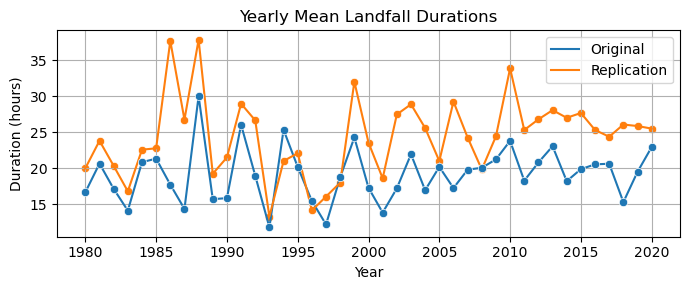

In [28]:
fig, ax = plt.subplots(1, figsize=(7,3))

# plot original mean landfalling durations
sns.lineplot(data=original_3b.to_frame(), x='Year', y='Landfall_duration', label='Original', ax=ax)
sns.scatterplot(data=original_3b.to_frame(), x='Year', y='Landfall_duration', zorder=4, ax=ax)
# plot replication mean landfalling durations
sns.lineplot(data=replication_3b.to_frame(), x='landfalling_start_date', y='duration_MBL_ASE', label='Replication', ax=ax)
sns.scatterplot(data=replication_3b.to_frame(), x='landfalling_start_date', y='duration_MBL_ASE', ax=ax)
ax.grid()
ax.set_xlabel('Year')
ax.set_ylabel('Duration (hours)')
ax.set_title('Yearly Mean Landfall Durations');
plt.tight_layout()

plt.savefig('../../output/plots/mbl_ase_durations.png', dpi=300)
#plt.show()

We see similarities with the original figure, including max duration upward spikes at 1988, 1999, 2010, and a notable downward spike at 1989 and 1993. We can also compute some summary statistics as well that assess the degree of overlap. We first compute the standard Pearson's correlation between the two time series themselves, and then the Pearson's correlation between the first-order differenced series to assess the degree of correlation in year-to-year jumps.

In [26]:
# the correlation with the raw count datasets
original_3b.corr(replication_3b)

np.float64(0.6042200752536682)

In [27]:
# the correlation with first-order differenced count datasets
original_3b.diff(periods=1).corr(replication_3b.diff(periods=1))

np.float64(0.6480401390289385)

We'll also compute the average and standard deviation of durations.

In [44]:
storm_lengths = mbl_ase_storms[mbl_ase_storms.landfalling_start_date.dt.year <= 2020].duration_MBL_ASE/np.timedelta64(1, 'h')

In [45]:
storm_lengths.mean()

np.float64(24.351156069364162)

In [46]:
storm_lengths.std()

np.float64(20.07812775861066)